# Financial Time Series Deep Learning Forecasting : Practice & Experiments

**Authored by Alexandre Mathias DONNAT, Sr - Télécom Paris**

### Forecasting task
I study the short-term forecasting of Apple (AAPL) closing price using:
- intrinsic market variables from AAPL,
- technical features,
- broader market variables such as the S&P 500 and the VIX,
- calendar-based time features.

### Models compared
I compare:
1. Simple baselines
2. A small MLP
3. A simplified PatchTST-like model in the univariate setting
4. A simplified PatchTST-like model in the multivariate setting

### Main questions
- Is forecasting with a complex model better than with simple baselines?
- Does multivariate information improve performance?
- Are financial time series predictable enough for deep models to provide a real advantage?

This notebook does not implement the exact official PatchTST paper architecture.  
Instead, I implement a lightweight PatchTST-inspired transformer that keeps the core intuition:
- split the time series into patches,
- embed those patches,
- model temporal relationships with a transformer encoder,
- output a multi-step forecast.

In [1]:
import math
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## 1. Data collection

I download daily market data from Yahoo Finance for:
- **AAPL** as the target asset,
- **^GSPC** as the broad market index,
- **^VIX** as a proxy for market fear / implied volatility.

The forecasting target will be the future AAPL closing price.

In [4]:
import yfinance as yf

start_date = "2015-01-01"
end_date = None

aapl = yf.download("AAPL", start=start_date, end=end_date, auto_adjust=True, progress=False)
sp500 = yf.download("^GSPC", start=start_date, end=end_date, auto_adjust=True, progress=False)
vix = yf.download("^VIX", start=start_date, end=end_date, auto_adjust=True, progress=False)

print("AAPL shape:", aapl.shape)
print("S&P500 shape:", sp500.shape)
print("VIX shape:", vix.shape)

AAPL shape: (2828, 5)
S&P500 shape: (2828, 5)
VIX shape: (2828, 5)


In [5]:
aapl.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.214890,24.682222,23.776350,24.671147,212818400
2015-01-05,23.532722,24.064285,23.346676,23.984551,257142000
2015-01-06,23.534939,23.794075,23.173918,23.596954,263188400
2015-01-07,23.864952,23.964619,23.632393,23.743135,160423600
2015-01-08,24.781889,24.839475,24.075353,24.192741,237458000


## 2. Feature engineering

I construct a multivariate dataset with three types of variables:

### A. Intrinsic AAPL variables
- Open, High, Low, Close, Volume
- Daily return
- Intraday spread and related features

### B. Technical features
- Rolling mean
- Rolling volatility

### C. External market features
- S&P 500 close and return
- VIX close and return

### D. Calendar features
- Day-of-week cyclic encoding
- Month cyclic encoding

In [6]:
df = pd.DataFrame(index=aapl.index)

# AAPL raw features
df["AAPL_Open"] = aapl["Open"]
df["AAPL_High"] = aapl["High"]
df["AAPL_Low"] = aapl["Low"]
df["AAPL_Close"] = aapl["Close"]
df["AAPL_Volume"] = aapl["Volume"]

# AAPL engineered features
df["AAPL_Return"] = df["AAPL_Close"].pct_change()
df["AAPL_LogReturn"] = np.log(df["AAPL_Close"] / df["AAPL_Close"].shift(1))
df["AAPL_HL_Spread"] = (df["AAPL_High"] - df["AAPL_Low"]) / df["AAPL_Close"]
df["AAPL_OC_Spread"] = (df["AAPL_Close"] - df["AAPL_Open"]) / df["AAPL_Open"]

df["AAPL_MA_5"] = df["AAPL_Close"].rolling(5).mean()
df["AAPL_MA_20"] = df["AAPL_Close"].rolling(20).mean()
df["AAPL_Vol_5"] = df["AAPL_Return"].rolling(5).std()
df["AAPL_Vol_20"] = df["AAPL_Return"].rolling(20).std()

# External market features
df["SP500_Close"] = sp500["Close"].reindex(df.index)
df["SP500_Return"] = df["SP500_Close"].pct_change()

df["VIX_Close"] = vix["Close"].reindex(df.index)
df["VIX_Return"] = df["VIX_Close"].pct_change()

# Calendar features
df["day_of_week"] = df.index.dayofweek
df["month"] = df.index.month

df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# Final cleanup
df = df.drop(columns=["day_of_week", "month"])
df = df.dropna().copy()

print(df.shape)
df.head()

(2808, 21)


,AAPL_Open,AAPL_High,AAPL_Low,AAPL_Close,AAPL_Volume,AAPL_Return,AAPL_LogReturn,AAPL_HL_Spread,AAPL_OC_Spread,AAPL_MA_5,...,AAPL_Vol_5,AAPL_Vol_20,SP500_Close,SP500_Return,VIX_Close,VIX_Return,dow_sin,dow_cos,month_sin,month_cos
Date,,,,,,,,,,,,,,,,,,,,,
2015-02-02,26.146235,26.394296,25.709910,26.274694,250956400,0.012547,0.012469,0.026047,0.004913,25.654098,...,0.036233,0.023813,2020.849976,0.012962,19.430000,-0.073438,0.000000,1.000000,0.866025,0.5
2015-02-03,26.245902,26.376577,26.048781,26.279125,207662800,0.000169,0.000169,0.012474,0.001266,26.075360,...,0.027687,0.022587,2050.030029,0.014439,17.330000,-0.108080,0.781831,0.623490,0.866025,0.5
2015-02-04,26.245909,26.691094,26.203827,26.480682,280598800,0.007670,0.007641,0.018401,0.008945,26.263623,...,0.016790,0.022551,2041.510010,-0.004156,18.330000,0.057703,0.974928,-0.222521,0.866025,0.5
2015-02-05,26.687475,26.734171,26.516259,26.669687,168984800,0.007137,0.007112,0.008171,-0.000667,26.330661,...,0.010585,0.022477,2062.520020,0.010291,16.850000,-0.080742,0.433884,-0.900969,0.866025,0.5
2015-02-06,26.687471,26.738614,26.338368,26.445101,174826400,-0.008421,-0.008457,0.015135,-0.009082,26.429858,...,0.008142,0.021310,2055.469971,-0.003418,17.290001,0.026113,-0.433884,-0.900969,0.866025,0.5


## 3. Quick exploratory analysis

Before training any model, I inspect:
- the target time series,
- some external variables,
- basic correlations.

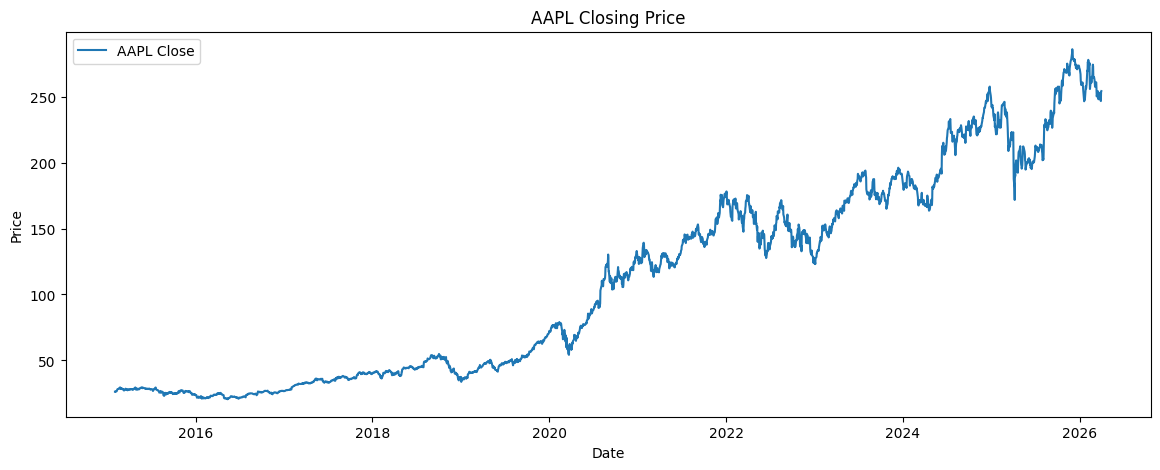

In [8]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["AAPL_Close"], label="AAPL Close")
plt.title("AAPL Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

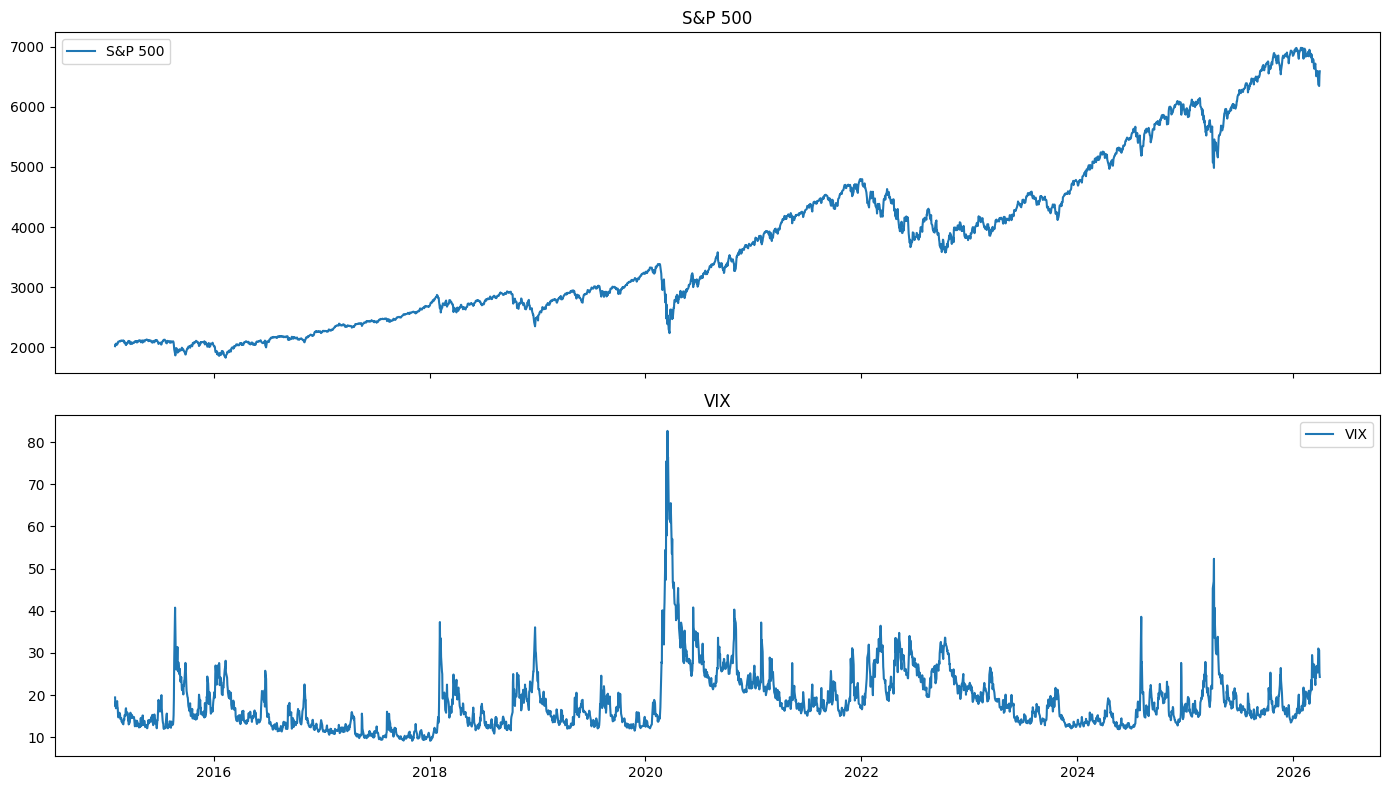

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df.index, df["SP500_Close"], label="S&P 500")
axes[0].set_title("S&P 500")
axes[0].legend()

axes[1].plot(df.index, df["VIX_Close"], label="VIX")
axes[1].set_title("VIX")
axes[1].legend()

plt.tight_layout()
plt.show()

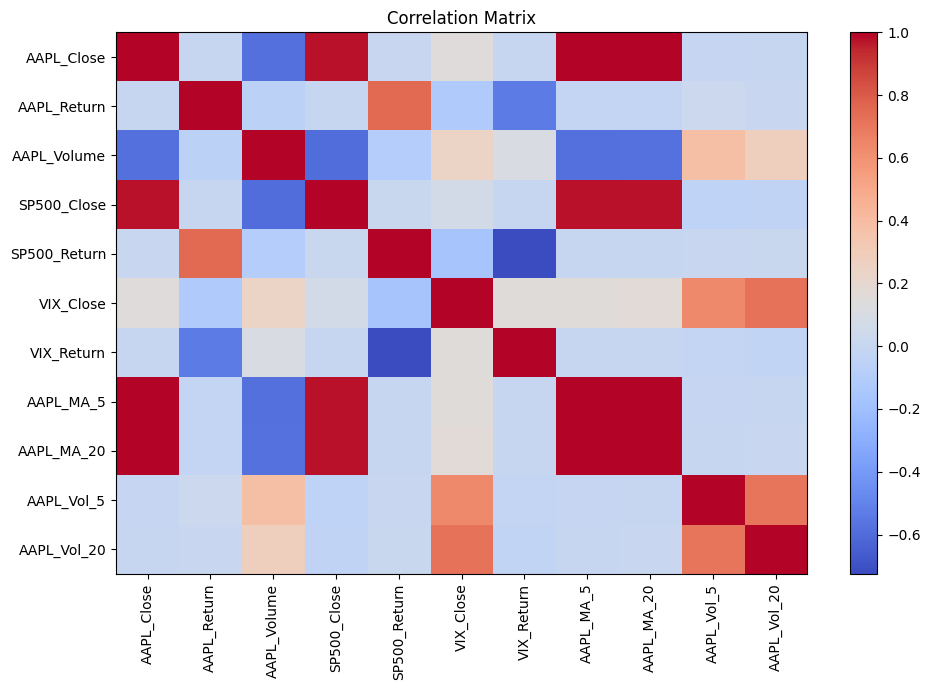

In [10]:
corr_cols = [
    "AAPL_Close", "AAPL_Return", "AAPL_Volume",
    "SP500_Close", "SP500_Return", "VIX_Close", "VIX_Return",
    "AAPL_MA_5", "AAPL_MA_20", "AAPL_Vol_5", "AAPL_Vol_20"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(10, 7))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 4. Forecasting setup

I define a multi-step forecasting problem:

- **context length**: 60 days  
- **prediction length**: 5 days  

This means:
- the model receives the last 60 observations,
- and must forecast the next 5 AAPL closing prices.

In [11]:
context_length = 60
prediction_length = 5

target_col = "AAPL_Close"

feature_cols = [
    "AAPL_Open", "AAPL_High", "AAPL_Low", "AAPL_Close", "AAPL_Volume",
    "AAPL_Return", "AAPL_LogReturn", "AAPL_HL_Spread", "AAPL_OC_Spread",
    "AAPL_MA_5", "AAPL_MA_20", "AAPL_Vol_5", "AAPL_Vol_20",
    "SP500_Close", "SP500_Return",
    "VIX_Close", "VIX_Return",
    "dow_sin", "dow_cos", "month_sin", "month_cos"
]

len(feature_cols)

21

## 5. Temporal train / validation / test split

A time series problem must respect chronological order.

I therefore use:
- 70% train
- 15% validation
- 15% test

No shuffling is performed.

In [12]:
n = len(df)

train_end = int(0.70 * n)
val_end = int(0.85 * n)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

Train: (1965, 21)
Val  : (421, 21)
Test : (422, 21)


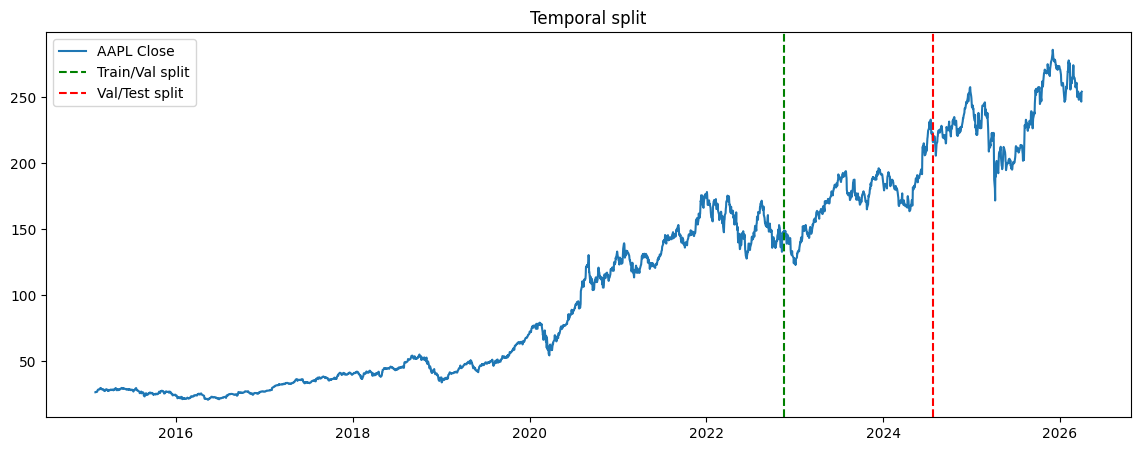

In [13]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df[target_col], label="AAPL Close")
plt.axvline(df.index[train_end], color="green", linestyle="--", label="Train/Val split")
plt.axvline(df.index[val_end], color="red", linestyle="--", label="Val/Test split")
plt.title("Temporal split")
plt.legend()
plt.show()

## 6. Scaling

To avoid leakage:
- I fit the scalers **only on the training set**
- then apply them to validation and test data

I use:
- one scaler for the input features
- one scaler for the target

In [14]:
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

feature_scaler.fit(train_df[feature_cols])
target_scaler.fit(train_df[[target_col]])

X_all_scaled = feature_scaler.transform(df[feature_cols])
y_all_scaled = target_scaler.transform(df[[target_col]]).reshape(-1)

X_all_scaled.shape, y_all_scaled.shape

((2808, 21), (2808,))

## 7. Window construction

I transform the time series into a supervised learning dataset.

For each time index \( t \):
- the input window contains the previous 60 time steps,
- the target contains the next 5 AAPL prices.

A window is assigned to train / validation / test according to the position of its forecast target.

In [15]:
def create_windows(X, y, context_length, prediction_length, train_end, val_end):
    X_windows = []
    y_windows = []
    split_labels = []

    n = len(X)

    for end_context in range(context_length, n - prediction_length + 1):
        start_context = end_context - context_length
        end_target = end_context + prediction_length

        x_win = X[start_context:end_context]
        y_win = y[end_context:end_target]

        # Split decided by the first predicted point
        target_start_idx = end_context

        if target_start_idx < train_end:
            split = "train"
        elif target_start_idx < val_end:
            split = "val"
        else:
            split = "test"

        X_windows.append(x_win)
        y_windows.append(y_win)
        split_labels.append(split)

    return np.array(X_windows), np.array(y_windows), np.array(split_labels)

X_windows, y_windows, split_labels = create_windows(
    X_all_scaled,
    y_all_scaled,
    context_length,
    prediction_length,
    train_end,
    val_end
)

print("X_windows:", X_windows.shape)
print("y_windows:", y_windows.shape)

X_windows: (2744, 60, 21)
y_windows: (2744, 5)


In [16]:
X_train = X_windows[split_labels == "train"]
y_train = y_windows[split_labels == "train"]

X_val = X_windows[split_labels == "val"]
y_val = y_windows[split_labels == "val"]

X_test = X_windows[split_labels == "test"]
y_test = y_windows[split_labels == "test"]

print("Train windows:", X_train.shape, y_train.shape)
print("Val windows  :", X_val.shape, y_val.shape)
print("Test windows :", X_test.shape, y_test.shape)

Train windows: (1905, 60, 21) (1905, 5)
Val windows  : (421, 60, 21) (421, 5)
Test windows : (418, 60, 21) (418, 5)


## 8. Dataset and DataLoader

In [17]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 64

train_ds = TimeSeriesDataset(X_train, y_train)
val_ds = TimeSeriesDataset(X_val, y_val)
test_ds = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

## 9. Baselines

Before using deep learning, I define very simple baselines.

### Baseline 1 — Last value
The future is predicted as the last observed closing price repeated over the horizon.

### Baseline 2 — Mean of the recent context
The future is predicted as the mean of the recent closing prices in the context window, repeated over the horizon.

These baselines are important because many complex models fail to beat them consistently on noisy financial data.

In [18]:
close_idx = feature_cols.index("AAPL_Close")

def inverse_transform_target(y_scaled):
    return target_scaler.inverse_transform(y_scaled.reshape(-1, 1)).reshape(y_scaled.shape)

def baseline_last_value(X):
    last_close = X[:, -1, close_idx]
    preds = np.repeat(last_close[:, None], prediction_length, axis=1)
    return preds

def baseline_context_mean(X):
    mean_close = X[:, :, close_idx].mean(axis=1)
    preds = np.repeat(mean_close[:, None], prediction_length, axis=1)
    return preds

In [20]:
def compute_metrics(y_true_scaled, y_pred_scaled, prefix=""):
    y_true = inverse_transform_target(y_true_scaled)
    y_pred = inverse_transform_target(y_pred_scaled)

    mae = mean_absolute_error(y_true.reshape(-1), y_pred.reshape(-1))
    mse = mean_squared_error(y_true.reshape(-1), y_pred.reshape(-1))
    rmse = np.sqrt(mse)

    return {
        f"{prefix}MAE": mae,
        f"{prefix}RMSE": rmse
    }

baseline_last_pred = baseline_last_value(X_test)
baseline_mean_pred = baseline_context_mean(X_test)

baseline_last_metrics = compute_metrics(y_test, baseline_last_pred)
baseline_mean_metrics = compute_metrics(y_test, baseline_mean_pred)

baseline_last_metrics, baseline_mean_metrics

({'MAE': 5.034405116031045, 'RMSE': np.float64(7.2164375138411065)},
 {'MAE': 12.598972753619087, 'RMSE': np.float64(15.637626219403273)})

## 10. Neural models

I now define three learned models:

### A. MLP
A simple feedforward model on the flattened input window.

### B. PatchTST-like Univariate
A transformer-based model that only uses the AAPL closing price.

### C. PatchTST-like Multivariate
A transformer-based model that uses all available features.

Again, this is a **lightweight educational implementation**, not the full original research model.

In [21]:
class MLPForecaster(nn.Module):
    def __init__(self, context_length, n_features, pred_len, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(context_length * n_features, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, pred_len)
        )

    def forward(self, x):
        # x: [B, L, C]
        x = x.reshape(x.size(0), -1)
        return self.net(x)

In [22]:
class PatchTSTLite(nn.Module):
    def __init__(
        self,
        context_length,
        n_features,
        pred_len,
        patch_len=10,
        stride=5,
        d_model=64,
        n_heads=4,
        n_layers=2,
        dropout=0.1
    ):
        super().__init__()

        self.context_length = context_length
        self.n_features = n_features
        self.pred_len = pred_len
        self.patch_len = patch_len
        self.stride = stride

        self.n_patches = 1 + (context_length - patch_len) // stride
        if self.n_patches <= 0:
            raise ValueError("Invalid patch_len/stride for the chosen context_length.")

        self.patch_proj = nn.Linear(patch_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=2 * d_model,
            dropout=dropout,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.head = nn.Sequential(
            nn.Linear(n_features * d_model, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, pred_len)
        )

    def forward(self, x):
        # x: [B, L, C]
        B, L, C = x.shape

        # [B, C, L]
        x = x.transpose(1, 2)

        # unfold on time dimension -> [B, C, n_patches, patch_len]
        x = x.unfold(dimension=2, size=self.patch_len, step=self.stride)

        # project patches
        x = self.patch_proj(x)  # [B, C, n_patches, d_model]

        # merge B and C
        x = x.reshape(B * C, self.n_patches, -1)

        # transformer
        x = self.encoder(x)  # [B*C, n_patches, d_model]

        # mean pool over patches
        x = x.mean(dim=1)  # [B*C, d_model]

        # reshape back
        x = x.reshape(B, C, -1)  # [B, C, d_model]

        # flatten channels
        x = x.reshape(B, -1)  # [B, C*d_model]

        return self.head(x)

## 11. Training utilities

In [23]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return np.mean(losses)


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    model.eval()
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        losses.append(loss.item())

    return np.mean(losses)


@torch.no_grad()
def predict_model(model, loader, device):
    model.eval()
    preds_all = []
    y_all = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).cpu().numpy()

        preds_all.append(preds)
        y_all.append(y_batch.numpy())

    return np.vstack(preds_all), np.vstack(y_all)

In [24]:
def fit_model(
    model,
    train_loader,
    val_loader,
    n_epochs=30,
    lr=1e-3,
    weight_decay=1e-5,
    patience=7
):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0

    history = {"train_loss": [], "val_loss": []}

    for epoch in range(1, n_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.5f} | val_loss={val_loss:.5f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

## 12. Helper function for plotting training curves

In [25]:
def plot_history(history, title="Training history"):
    plt.figure(figsize=(8, 4))
    plt.plot(history["train_loss"], label="Train loss")
    plt.plot(history["val_loss"], label="Val loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.legend()
    plt.show()

## 13. MLP experiment

Epoch 01 | train_loss=0.17309 | val_loss=0.22711
Epoch 02 | train_loss=0.05621 | val_loss=0.24655
Epoch 03 | train_loss=0.04293 | val_loss=0.07071
Epoch 04 | train_loss=0.03713 | val_loss=0.07186
Epoch 05 | train_loss=0.03227 | val_loss=0.04642
Epoch 06 | train_loss=0.03101 | val_loss=0.12830
Epoch 07 | train_loss=0.03037 | val_loss=0.18998
Epoch 08 | train_loss=0.02608 | val_loss=0.31087
Epoch 09 | train_loss=0.03157 | val_loss=0.14129
Epoch 10 | train_loss=0.02617 | val_loss=0.05292
Epoch 11 | train_loss=0.02379 | val_loss=0.03520
Epoch 12 | train_loss=0.02389 | val_loss=0.09189
Epoch 13 | train_loss=0.02148 | val_loss=0.04454
Epoch 14 | train_loss=0.02174 | val_loss=0.19551
Epoch 15 | train_loss=0.02017 | val_loss=0.09886
Epoch 16 | train_loss=0.02118 | val_loss=0.06735
Epoch 17 | train_loss=0.01985 | val_loss=0.15763
Epoch 18 | train_loss=0.02116 | val_loss=0.10597
Early stopping triggered.


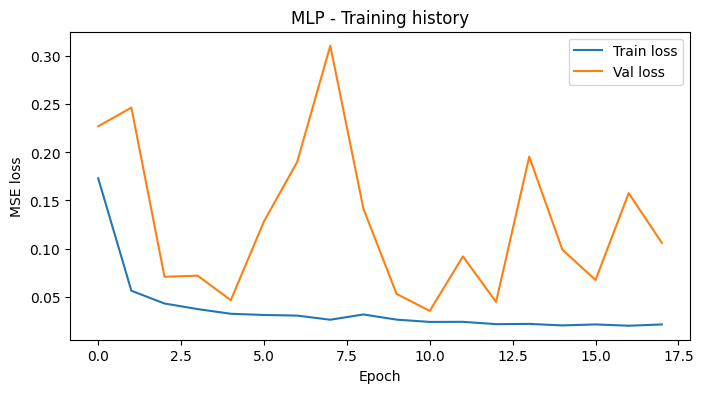

In [26]:
mlp_model = MLPForecaster(
    context_length=context_length,
    n_features=len(feature_cols),
    pred_len=prediction_length,
    hidden_dim=128
)

mlp_model, mlp_history = fit_model(
    mlp_model,
    train_loader,
    val_loader,
    n_epochs=30,
    lr=1e-3,
    patience=7
)

plot_history(mlp_history, title="MLP - Training history")

In [27]:
mlp_preds_scaled, mlp_true_scaled = predict_model(mlp_model, test_loader, device)
mlp_metrics = compute_metrics(mlp_true_scaled, mlp_preds_scaled)
mlp_metrics

{'MAE': 8.62112045288086, 'RMSE': np.float64(10.959043723941507)}

## 14. PatchTST-like univariate experiment

In the univariate setting, I only keep the AAPL closing price channel.

In [28]:
uni_feature_idx = [close_idx]

X_train_uni = X_train[:, :, uni_feature_idx]
X_val_uni = X_val[:, :, uni_feature_idx]
X_test_uni = X_test[:, :, uni_feature_idx]

train_uni_ds = TimeSeriesDataset(X_train_uni, y_train)
val_uni_ds = TimeSeriesDataset(X_val_uni, y_val)
test_uni_ds = TimeSeriesDataset(X_test_uni, y_test)

train_uni_loader = DataLoader(train_uni_ds, batch_size=batch_size, shuffle=True)
val_uni_loader = DataLoader(val_uni_ds, batch_size=batch_size, shuffle=False)
test_uni_loader = DataLoader(test_uni_ds, batch_size=batch_size, shuffle=False)

X_train_uni.shape

(1905, 60, 1)

Epoch 01 | train_loss=0.14586 | val_loss=0.52412
Epoch 02 | train_loss=0.03897 | val_loss=0.27806
Epoch 03 | train_loss=0.03154 | val_loss=0.26464
Epoch 04 | train_loss=0.03030 | val_loss=0.33488
Epoch 05 | train_loss=0.02826 | val_loss=0.22182
Epoch 06 | train_loss=0.02507 | val_loss=0.28778
Epoch 07 | train_loss=0.02529 | val_loss=0.32336
Epoch 08 | train_loss=0.02604 | val_loss=0.11952
Epoch 09 | train_loss=0.02362 | val_loss=0.17542
Epoch 10 | train_loss=0.02407 | val_loss=0.18188
Epoch 11 | train_loss=0.02323 | val_loss=0.32885
Epoch 12 | train_loss=0.01967 | val_loss=0.15037
Epoch 13 | train_loss=0.02005 | val_loss=0.16329
Epoch 14 | train_loss=0.01932 | val_loss=0.14939
Epoch 15 | train_loss=0.02053 | val_loss=0.22965
Early stopping triggered.


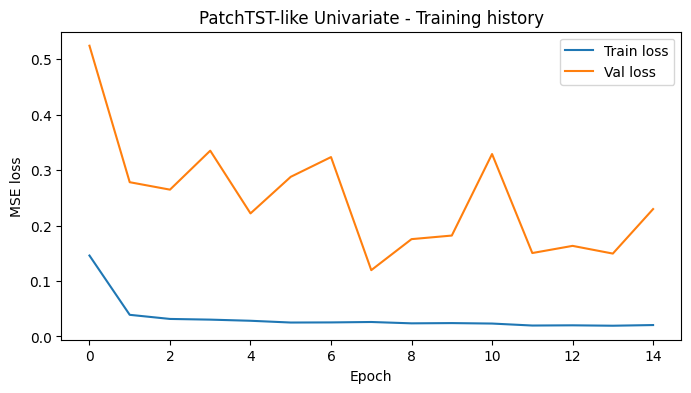

In [29]:
patch_uni_model = PatchTSTLite(
    context_length=context_length,
    n_features=1,
    pred_len=prediction_length,
    patch_len=10,
    stride=5,
    d_model=64,
    n_heads=4,
    n_layers=2,
    dropout=0.1
)

patch_uni_model, patch_uni_history = fit_model(
    patch_uni_model,
    train_uni_loader,
    val_uni_loader,
    n_epochs=30,
    lr=1e-3,
    patience=7
)

plot_history(patch_uni_history, title="PatchTST-like Univariate - Training history")

In [30]:
patch_uni_preds_scaled, patch_uni_true_scaled = predict_model(patch_uni_model, test_uni_loader, device)
patch_uni_metrics = compute_metrics(patch_uni_true_scaled, patch_uni_preds_scaled)
patch_uni_metrics

{'MAE': 51.6796875, 'RMSE': np.float64(56.048517190884496)}

## 15. PatchTST-like multivariate experiment

In the multivariate setting, I use all engineered features.

Epoch 01 | train_loss=0.12215 | val_loss=0.74135
Epoch 02 | train_loss=0.02997 | val_loss=0.85490
Epoch 03 | train_loss=0.02322 | val_loss=0.93254
Epoch 04 | train_loss=0.01779 | val_loss=0.66632
Epoch 05 | train_loss=0.01654 | val_loss=0.68560
Epoch 06 | train_loss=0.01483 | val_loss=0.80720
Epoch 07 | train_loss=0.01444 | val_loss=0.86186
Epoch 08 | train_loss=0.01598 | val_loss=0.75312
Epoch 09 | train_loss=0.01435 | val_loss=0.82834
Epoch 10 | train_loss=0.01354 | val_loss=0.92070
Epoch 11 | train_loss=0.01262 | val_loss=0.87655
Early stopping triggered.


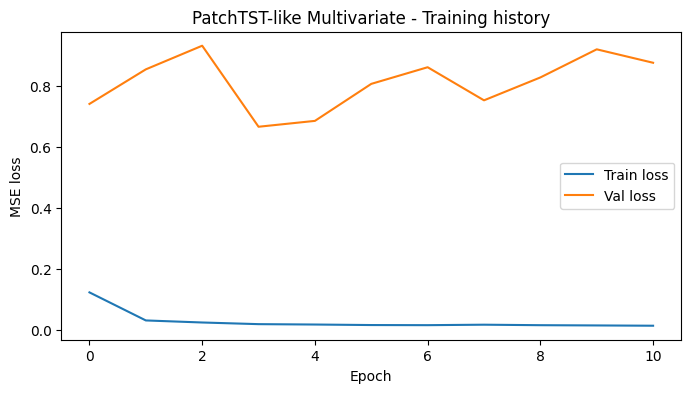

In [31]:
patch_multi_model = PatchTSTLite(
    context_length=context_length,
    n_features=len(feature_cols),
    pred_len=prediction_length,
    patch_len=10,
    stride=5,
    d_model=64,
    n_heads=4,
    n_layers=2,
    dropout=0.1
)

patch_multi_model, patch_multi_history = fit_model(
    patch_multi_model,
    train_loader,
    val_loader,
    n_epochs=30,
    lr=1e-3,
    patience=7
)

plot_history(patch_multi_history, title="PatchTST-like Multivariate - Training history")

In [32]:
patch_multi_preds_scaled, patch_multi_true_scaled = predict_model(patch_multi_model, test_loader, device)
patch_multi_metrics = compute_metrics(patch_multi_true_scaled, patch_multi_preds_scaled)
patch_multi_metrics

{'MAE': 78.7923583984375, 'RMSE': np.float64(82.12660826526474)}

## 16. Global comparison

In [33]:
results = pd.DataFrame([
    {"Model": "Baseline - Last Value", **baseline_last_metrics},
    {"Model": "Baseline - Context Mean", **baseline_mean_metrics},
    {"Model": "MLP - Multivariate", **mlp_metrics},
    {"Model": "PatchTST-like - Univariate", **patch_uni_metrics},
    {"Model": "PatchTST-like - Multivariate", **patch_multi_metrics},
])

results = results.sort_values("RMSE").reset_index(drop=True)
results

,Model,MAE,RMSE
0,Baseline - Last Value,5.034405,7.216438
1,MLP - Multivariate,8.621120,10.959044
2,Baseline - Context Mean,12.598973,15.637626
3,PatchTST-like - Univariate,51.679688,56.048517
4,PatchTST-like - Multivariate,78.792358,82.126608


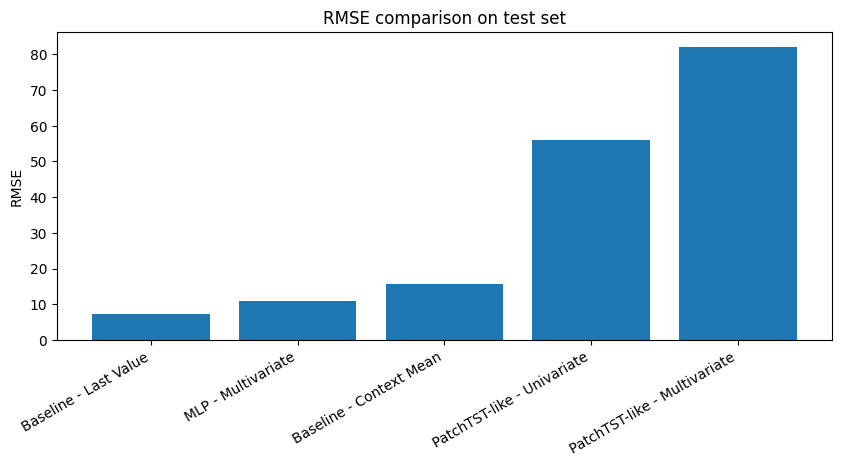

In [34]:
plt.figure(figsize=(10, 4))
plt.bar(results["Model"], results["RMSE"])
plt.xticks(rotation=30, ha="right")
plt.title("RMSE comparison on test set")
plt.ylabel("RMSE")
plt.show()

## 17. Visual inspection of forecasts

Numerical metrics are useful, but visual inspection also matters.

I now compare the predicted trajectories of a few test examples.

In [35]:
def plot_forecast_examples(y_true_scaled, y_pred_scaled, n_examples=5, title="Forecast examples"):
    y_true = inverse_transform_target(y_true_scaled)
    y_pred = inverse_transform_target(y_pred_scaled)

    n_examples = min(n_examples, len(y_true))

    fig, axes = plt.subplots(n_examples, 1, figsize=(10, 3 * n_examples))

    if n_examples == 1:
        axes = [axes]

    for i in range(n_examples):
        axes[i].plot(range(prediction_length), y_true[i], marker="o", label="True")
        axes[i].plot(range(prediction_length), y_pred[i], marker="x", label="Pred")
        axes[i].set_title(f"{title} - Example {i+1}")
        axes[i].set_xlabel("Forecast step")
        axes[i].set_ylabel("Price")
        axes[i].legend()

    plt.tight_layout()
    plt.show()

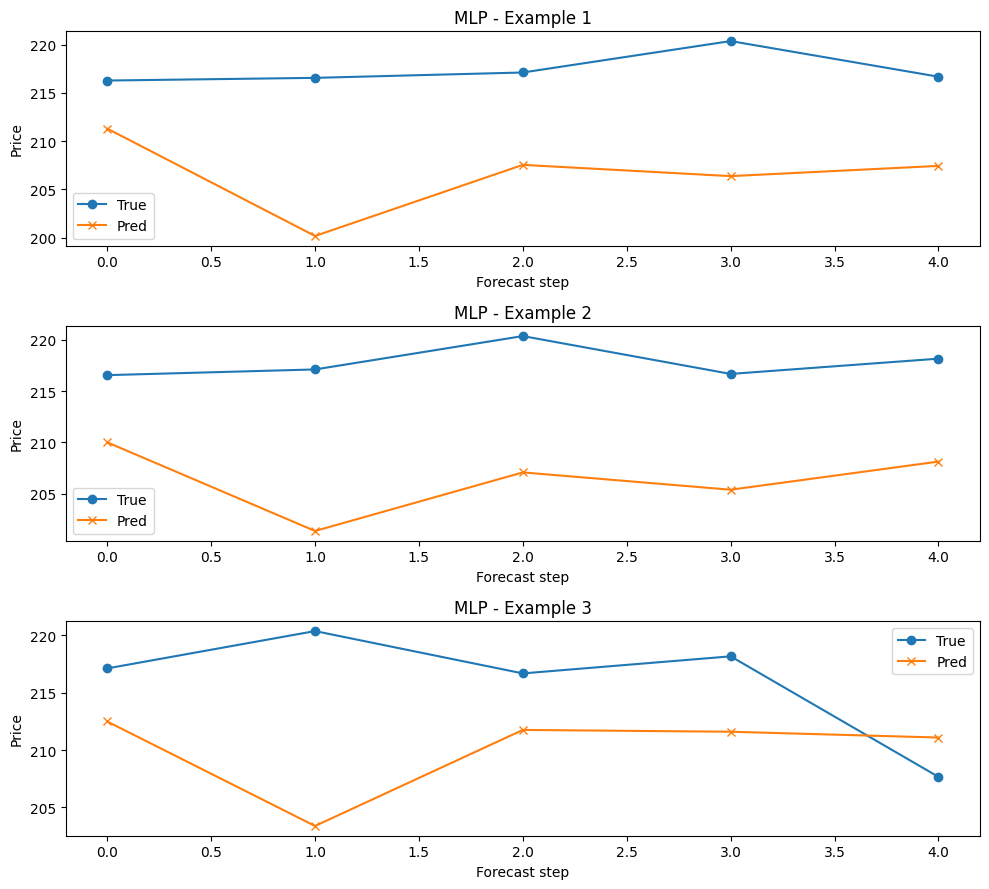

In [36]:
plot_forecast_examples(mlp_true_scaled, mlp_preds_scaled, n_examples=3, title="MLP")

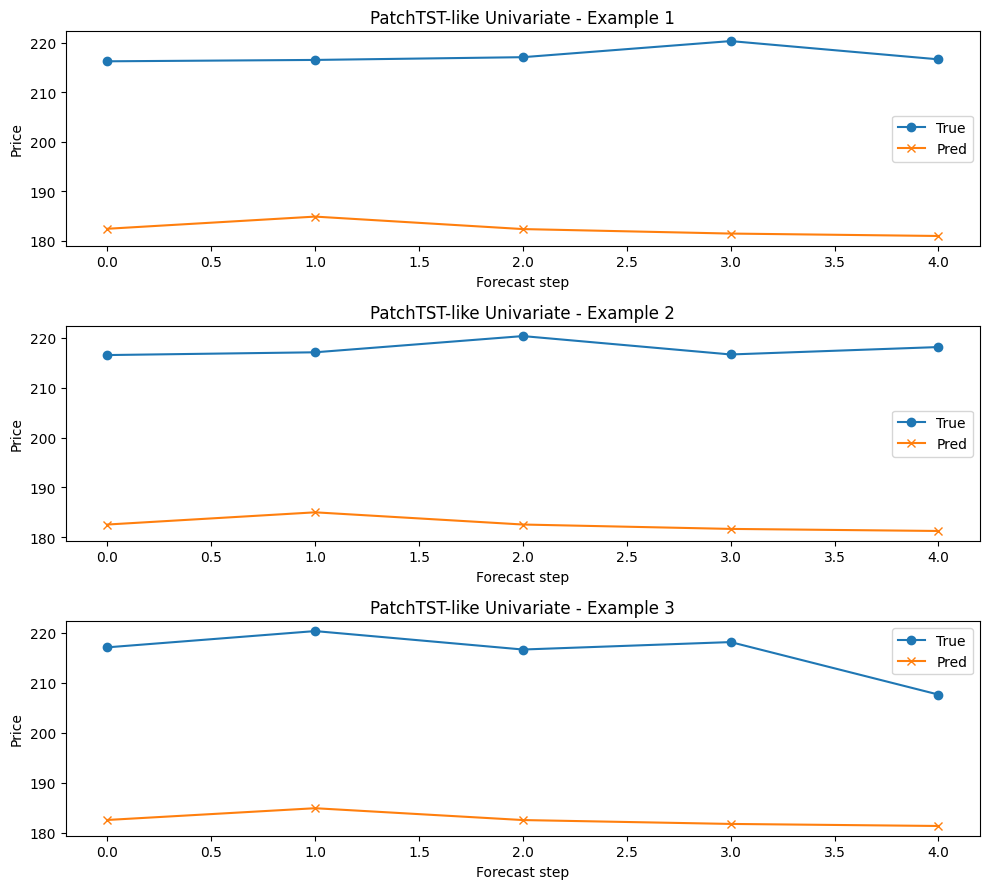

In [37]:
plot_forecast_examples(patch_uni_true_scaled, patch_uni_preds_scaled, n_examples=3, title="PatchTST-like Univariate")

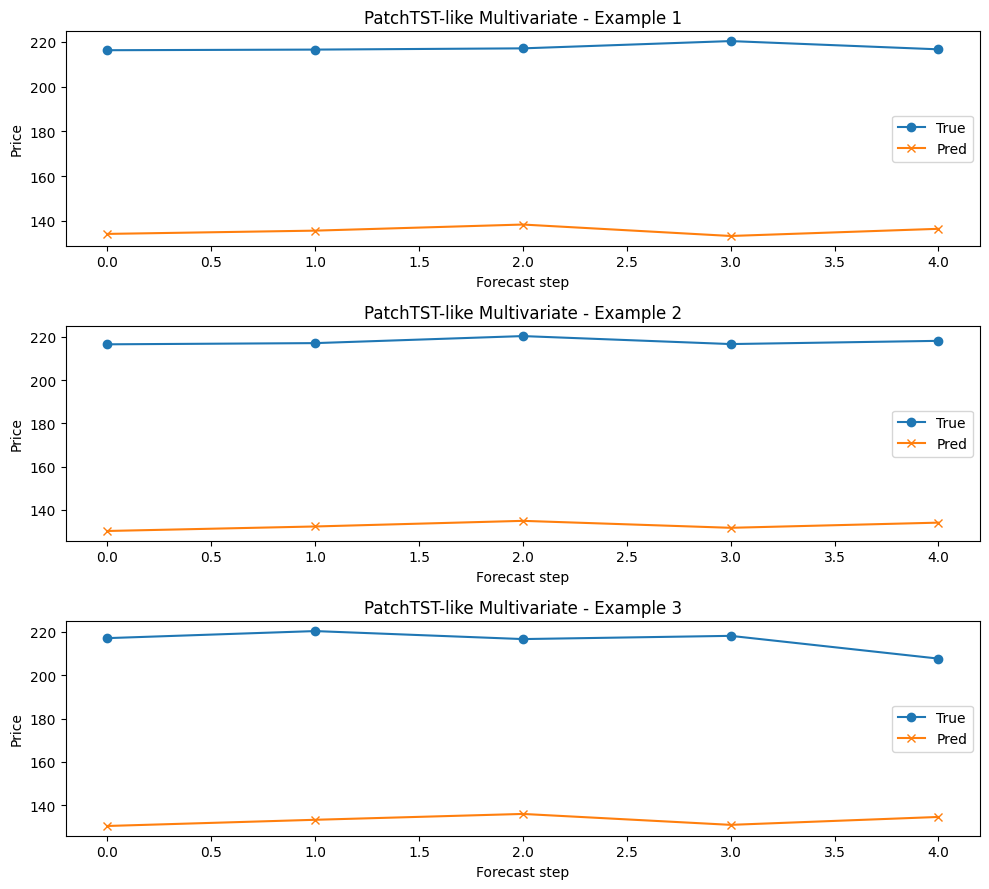

In [38]:
plot_forecast_examples(patch_multi_true_scaled, patch_multi_preds_scaled, n_examples=3, title="PatchTST-like Multivariate")

## 18. Horizon-wise error analysis

It is often useful to inspect how the error evolves across the forecast horizon:
- step 1,
- step 2,
- ...
- step 5.

Usually, the farther the horizon, the harder the problem.

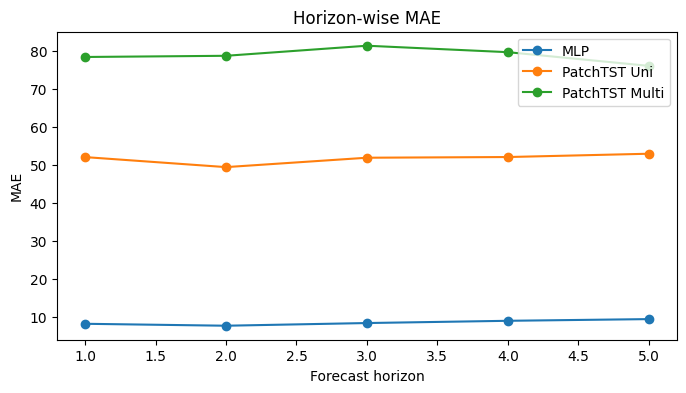

In [39]:
def horizon_wise_mae(y_true_scaled, y_pred_scaled):
    y_true = inverse_transform_target(y_true_scaled)
    y_pred = inverse_transform_target(y_pred_scaled)

    maes = []
    for h in range(y_true.shape[1]):
        mae_h = mean_absolute_error(y_true[:, h], y_pred[:, h])
        maes.append(mae_h)
    return maes

h_mae_mlp = horizon_wise_mae(mlp_true_scaled, mlp_preds_scaled)
h_mae_uni = horizon_wise_mae(patch_uni_true_scaled, patch_uni_preds_scaled)
h_mae_multi = horizon_wise_mae(patch_multi_true_scaled, patch_multi_preds_scaled)

plt.figure(figsize=(8, 4))
plt.plot(range(1, prediction_length + 1), h_mae_mlp, marker="o", label="MLP")
plt.plot(range(1, prediction_length + 1), h_mae_uni, marker="o", label="PatchTST Uni")
plt.plot(range(1, prediction_length + 1), h_mae_multi, marker="o", label="PatchTST Multi")
plt.title("Horizon-wise MAE")
plt.xlabel("Forecast horizon")
plt.ylabel("MAE")
plt.legend()
plt.show()

## Interpretation

The results of this notebook are very clear and actually quite instructive.

### Global ranking of the models

The test-set ranking is the following:

1. Baseline - Last Value  
   - MAE = 5.03  
   - RMSE = 7.22  

2. MLP - Multivariate  
   - MAE = 8.62  
   - RMSE = 10.96  

3. Baseline - Context Mean  
   - MAE = 12.60  
   - RMSE = 15.64  

4. PatchTST-like - Univariate  
   - MAE = 51.68  
   - RMSE = 56.05  

5. PatchTST-like - Multivariate  
   - MAE = 78.79  
   - RMSE = 82.13  

The most important observation is that the best model is not a deep model, but the naive last-value baseline.  
This means that, on this dataset and with this forecasting setup, simply repeating the most recent observed AAPL closing price is already a very strong strategy.

This is not surprising in finance. Over short horizons, daily asset prices are often highly persistent, and the next few values are usually close to the latest observed level. In that context, a naive persistence forecast is very hard to beat.

### Interpretation of the baselines

The last-value baseline performs best because it matches a key empirical property of short-term financial prices:  
they usually do not jump dramatically from one day to the next unless major news occurs.

The context-mean baseline performs worse because averaging the recent past tends to smooth the signal too much.  
When the price level has local momentum or recent drift, the average of the past 60 observations becomes too lagged and produces forecasts that are less reactive than the last observed value.

So even before looking at deep learning models, the baseline comparison already tells something important:

> for short-horizon price forecasting, persistence is a very strong benchmark and any complex model must beat it to justify its existence.

### Interpretation of the MLP results

The multivariate MLP is the best learned model, but it still does not beat the naive last-value baseline.

Its test performance remains reasonable:
- RMSE around 10.96,
- much better than the context-mean baseline,
- and dramatically better than both transformer-based models.

This suggests that the MLP is able to extract some useful structure from the multivariate input windows, but not enough to outperform the persistence benchmark.

The training curve also confirms that the MLP learns something:
- training loss decreases steadily,
- validation loss remains noisy,
- but the model still reaches a usable compromise before overfitting too much.

The forecast plots show another important pattern:  
the MLP tends to predict values that are systematically below the true future prices.  
So the model captures a rough level and local shape, but with a noticeable downward bias on the displayed examples.

This means the MLP is learning a coarse approximation of the local price regime, but not a highly accurate forecast of the exact future trajectory.

### Interpretation of the PatchTST-like models

Both PatchTST-like models perform extremely poorly.

#### Univariate PatchTST-like
- RMSE = 56.05

#### Multivariate PatchTST-like
- RMSE = 82.13

These errors are not just slightly worse than the baselines: they are massively worse, which means that these models failed to generalize properly in this experiment.

The forecast plots make this very visible:
- the univariate model predicts values around the low 180s while the true prices are around 210–220,
- the multivariate model is even worse, predicting values around 130–140.

So these models are not simply "less precise"; they are forecasting at the wrong price level entirely.

### What explains this failure?

Several factors probably contribute.

#### (a) Validation curves indicate strong overfitting
For both PatchTST-like models:
- training loss falls quickly to a very low level,
- validation loss stays high and unstable.

This is a classic sign of overfitting:
the model fits the training windows very well but fails to learn a representation that generalizes to unseen data.

The multivariate PatchTST-like model is the clearest case:
- train loss becomes almost zero,
- while validation loss remains extremely high.

So the model has high capacity, but the learned structure does not transfer to validation and test data.

#### (b) Financial data are noisy and weakly predictable
Transformer-style forecasting architectures often shine on structured datasets such as:
- electricity,
- traffic,
- weather,
- industrial signals.

Those domains often contain:
- strong seasonality,
- repeated medium-term patterns,
- more stable dependencies.

Daily stock prices are different:
- signal-to-noise ratio is much lower,
- relationships are unstable,
- past patterns do not necessarily repeat in a learnable way.

So a more complex architecture does not automatically help.  
In fact, it can hurt badly.

#### (c) This notebook uses a lightweight PatchTST-inspired implementation
Another important point is methodological honesty: this is not the full official PatchTST architecture, but a simplified educational implementation.

So the poor performance should not be interpreted as "PatchTST as a research model is bad".  
Rather, it should be interpreted as:

> this lightweight transformer-style implementation does not work well on this financial forecasting setup.

That distinction matters.

#### (d) Multivariate input may add noise rather than signal
The multivariate PatchTST-like model is even worse than the univariate one.

This suggests that adding features did not help the transformer here.  
Instead, the model may have been distracted by:
- irrelevant or unstable predictors,
- noisy market covariates,
- weakly informative engineered variables.

So in this case, more variables did not mean more predictive power.

### Horizon-wise analysis

The horizon-wise MAE plot also confirms the ranking:

- MLP remains by far the best learned model across all forecast steps,
- PatchTST-like Univariate is consistently bad,
- PatchTST-like Multivariate is consistently the worst.

Another interesting point is that the MLP error stays relatively stable from horizon 1 to horizon 5.  
This suggests that the model is not collapsing as the horizon grows; instead, it produces a moderately biased but stable forecast across the 5-day window.

By contrast, the transformer-style models are poor at every horizon, which means the problem is not just long-horizon drift.  
The issue is more fundamental: the predicted level itself is wrong.

### Main lesson from the experiment

The key lesson is not that "deep learning fails" in general.  
The real lesson is more precise:

- a strong naive baseline can dominate short-horizon financial forecasting,
- additional model complexity is only useful if the data contain exploitable structure,
- multivariate information is not automatically beneficial,
- and transformer-style models can overfit badly when the signal is weak and unstable.

In other words, the limiting factor here is not the lack of sophistication of the models.  
It is the difficulty of the underlying signal.

## Conclusion

This practical session reproduced the logic of a forecasting experiment on a substitute dataset built from Yahoo Finance data, using AAPL as the target series and additional market variables as external features.

The objective was to compare:
- simple baselines,
- a multivariate MLP,
- a univariate PatchTST-like model,
- and a multivariate PatchTST-like model.

### Main empirical conclusion

The clearest result of the notebook is that the best-performing method is the naive last-value baseline.

This is a strong and useful conclusion.  
It shows that, for short-horizon daily stock price forecasting, recent persistence is already extremely hard to beat.

The MLP provides the best learned-model performance, but it still remains worse than the naive baseline.  
The two PatchTST-like models perform very poorly and fail to generalize.

So the final ranking is not:
- "complex transformer > simple model > baseline"

but rather:

- naive persistence > moderate neural model > more complex transformer-like models

This result is actually intellectually valuable, because it goes against the simplistic belief that more advanced architectures automatically produce better forecasts.

### Methodological conclusion

This notebook also highlights several important methodological lessons:

1. Temporal baselines are essential  
   Without a last-value baseline, one could wrongly conclude that the MLP is "good" just because it is the best neural model.

2. Financial forecasting is structurally difficult  
   Asset prices are noisy, weakly predictable, and non-stationary.  
   This makes generalization much harder than in more structured forecasting domains.

3. Multivariate design must be justified  
   Adding more variables does not guarantee better performance.  
   Extra features can add noise, instability, and overfitting.

4. Complex architectures are not magic  
   Transformer-style models can be powerful, but only when the data contain enough repeatable structure to exploit.

5. Interpretation matters as much as training  
   A forecasting experiment is not just about fitting models.  
   It is about:
   - defining the task correctly,
   - avoiding leakage,
   - using proper train/validation/test splits,
   - benchmarking against simple alternatives,
   - and interpreting results honestly.

### Final takeaway

The main takeaway of this practical session is that model complexity must match the nature of the signal.

For highly structured data such as electricity, weather, or traffic, transformer-based forecasting models can be very relevant.  
For short-horizon financial prices, however, the signal is much weaker and simpler baselines can remain very competitive or even superior.

Therefore, the most important lesson of this notebook is not that one particular model wins.  
It is that a rigorous forecasting workflow requires:
- strong baselines,
- careful validation,
- critical interpretation,
- and methodological honesty.

In that sense, this practical session is successful: it shows that good forecasting practice is not about using the most fashionable model, but about understanding what the data truly allow us to predict.